# 03 Model Training & Evaluation

Trains the risk-tier classifier (Gradient Boosting) that predicts a customer's credit risk tier (`Approved_Flag`: P1-P4), and a second model (Random Forest Regressor) that predicts an appropriate loan amount, from the banking + CIBIL bureau features. The tier classifier is the eligibility decision; the loan-amount regressor is the "how much loan" model.

## 1. Imports and Load Featured Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               RandomForestRegressor)
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, r2_score, mean_absolute_error)

pd.set_option('display.max_columns', None)

df = pd.read_csv("../data/processed/featured_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (51336, 79)


,PROSPECTID,Total_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL,time_since_recent_payment,num_times_delinquent,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_std,num_std_6mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_lss,num_lss_6mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,time_since_recent_enq,enq_L12m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_Flag,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag,NETMONTHLYINCOME_Capped,Age_Group,Income_Segment,Credit_Score_Band,Income_TL_Ratio,Credit_Health_Score,MARITALSTATUS_enc,EDUCATION_enc,GENDER_enc,last_prod_enq2_enc,first_prod_enq2_enc
0,1,5,1,0,0,0.000,0.0,0.200,0,0,0.00,0.0,0,0,0,0,1,0,4,4,0,72.0,18.0,549.0,11,29,0,0,0.0,0.0,0,21,5,0,0,0,0,0,0,0,29,6.0,0.0,0.0,0.0,6.0,0.0,566.0,0.0,0.0,Married,12TH,48,M,51000,114,0.0,0.798,0,1,0.0,0.0,1,0,PL,PL,696,P2,51000,45-54,Mid (30K-60K),Fair (650-699),51000.0,56.10,0,0,1,4,4
1,2,1,1,0,0,0.000,0.0,1.000,1,0,1.00,0.0,0,0,0,1,0,0,0,1,0,7.0,7.0,47.0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,209.0,1.0,0.0,Single,GRADUATE,23,F,19000,50,0.0,0.370,0,0,0.0,0.0,0,0,ConsumerLoan,ConsumerLoan,685,P2,19000,18-24,Lower-Mid (15K-30K),Fair (650-699),19000.0,52.11,1,1,0,2,2
2,3,8,8,1,0,0.125,0.0,1.000,2,0,0.25,0.0,1,1,0,6,1,0,0,6,0,47.0,2.0,302.0,9,25,1,9,25.0,25.0,0,10,5,0,0,0,0,0,0,0,25,4.0,0.0,0.0,0.0,0.0,0.0,587.0,0.0,0.0,Married,SSC,40,M,18,191,0.5,0.585,0,0,0.0,0.0,1,0,ConsumerLoan,others,693,P2,8000,35-44,Low (<15K),Fair (650-699),1000.0,51.13,0,5,1,2,5
3,4,1,1,1,0,1.000,0.0,1.000,1,0,1.00,0.0,1,0,0,0,0,0,0,1,1,5.0,5.0,74.0,0,0,0,0,0.0,0.0,0,5,4,0,0,0,0,0,0,0,0,3.0,0.0,0.0,0.0,0.0,0.0,75.0,2.0,1.0,Married,SSC,34,M,10000,246,1.0,0.990,0,0,0.0,0.0,0,0,others,others,673,P2,10000,25-34,Low (<15K),Fair (650-699),10000.0,29.62,0,5,1,5,5
4,5,3,1,0,0,0.000,0.0,0.333,0,0,0.00,0.0,0,1,0,0,0,0,0,0,2,131.0,32.0,583.0,0,0,0,0,0.0,0.0,0,53,4,0,0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,3951.0,0.0,0.0,Married,POST-GRADUATE,48,M,15000,75,0.0,0.000,0,0,0.0,0.0,0,0,AL,AL,753,P1,15000,45-54,Low (<15K),Excellent (750+),15000.0,71.55,0,3,1,0,0


## 2. Define Features and Target

We drop identifiers, the raw (outlier-prone) income column in favor of `NETMONTHLYINCOME_Capped`, the raw categorical text columns in favor of their `_enc` versions, and the reporting-only bins (redundant with the numeric columns they were derived from).

In [2]:
# TARGET (y) = what we want to predict: the risk tier P1-P4.
# X = the inputs. I drop the id, the target itself, the raw text columns (kept their
# encoded versions), the raw income (kept the capped one) and the display-only bins.
TARGET = 'Approved_Flag'
DROP_COLS = ['PROSPECTID', TARGET, 'NETMONTHLYINCOME',
             'MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2',
             'Age_Group', 'Income_Segment', 'Credit_Score_Band']
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
print(f"{len(FEATURE_COLS)} features:")
print(FEATURE_COLS)

X = df[FEATURE_COLS]   # the 68 input columns
y = df[TARGET]         # the answer we're training the model to predict

68 features:
['Total_TL', 'Tot_Active_TL', 'Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M', 'pct_tl_closed_L6M', 'pct_active_tl', 'Total_TL_opened_L12M', 'Tot_TL_closed_L12M', 'pct_tl_open_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL', 'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment', 'num_times_delinquent', 'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts', 'max_deliq_6mts', 'max_deliq_12mts', 'num_times_30p_dpd', 'num_std', 'num_std_6mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_lss', 'num_lss_6mts', 'recent_level_of_deliq', 'tot_enq', 'CC_enq', 'CC_enq_L6m', 'CC_enq_L12m', 'PL_enq', 'PL_enq_L6m', 'time_since_recent_enq', 'enq_L12m', 'enq_L3m', 'AGE', 'Time_With_Curr_Empr', 'pct_opened_TLs_L6m_of_L12m', 'pct_currentBal_all_TL', 'CC_Flag', 'PL_Flag', 'pct_PL_enq_L6m_of_L12m', 'pct_CC_enq_L6m_of_L12m', 'HL_Flag', 'G

## 3. Train / Validation / Test Split

70/15/15 stratified split on the target, so each risk tier is represented proportionally in all three sets.

In [3]:
# Split the data into 3 parts so I test the model on data it has NEVER seen:
#  - Train (70%)      -> the model learns from this
#  - Validation (15%) -> used to pick the best algorithm
#  - Test (15%)       -> only touched once at the very end for an honest score
# stratify=y keeps the P1-P4 mix the same in every part. random_state=42 = reproducible.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"Train: {len(X_train):,}  Validation: {len(X_val):,}  Test: {len(X_test):,}")
print(f"Total: {len(X_train) + len(X_val) + len(X_test):,} (dataset has {len(df):,} rows)")

Train: 35,935  Validation: 7,700  Test: 7,701
Total: 51,336 (dataset has 51,336 rows)


## 4. Classification — Train the Risk-Tier Model

We train the Gradient Boosting classifier (chosen during development as the best performer) and evaluate it on the held-out validation set before the final test-set check.

In [4]:
# The risk-tier model. Gradient Boosting was the best performer in development, so it
# is the single classifier the project trains and ships.
classifiers = {
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
}

clf_results = []
fitted_classifiers = {}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)              # train on the training set
    val_pred = clf.predict(X_val)          # predict on the validation set
    acc = accuracy_score(y_val, val_pred)  # how often it was right
    f1 = f1_score(y_val, val_pred, average='macro')   # balanced score across all 4 tiers
    clf_results.append({"Model": name, "Val_Accuracy": acc, "Val_F1_Macro": f1})
    fitted_classifiers[name] = clf
    print(f"{name:22s} val_accuracy={acc:.4f}  val_f1_macro={f1:.4f}")

clf_results_df = pd.DataFrame(clf_results).sort_values('Val_Accuracy', ascending=False)
clf_results_df

Gradient Boosting      val_accuracy=0.9947  val_f1_macro=0.9895


,Model,Val_Accuracy,Val_F1_Macro
0,Gradient Boosting,0.994675,0.989484


## 5. Confirm the Classifier on the Test Set

In [5]:
# Take the winner from the validation round and give it the final exam on the TEST
# set (data it has never seen). This is the honest, real-world accuracy to report.
best_clf_name = clf_results_df.iloc[0]['Model']
best_clf = fitted_classifiers[best_clf_name]
print(f"Best model on validation: {best_clf_name}")

test_pred = best_clf.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
print(f"\nTest accuracy: {test_acc:.4f}\n")
# classification_report shows precision/recall/F1 for each tier separately
print(classification_report(y_test, test_pred))

Best model on validation: Gradient Boosting

Test accuracy: 0.9949

              precision    recall  f1-score   support

          P1       0.99      0.96      0.98       871
          P2       1.00      1.00      1.00      4830
          P3       0.97      0.99      0.98      1118
          P4       1.00      1.00      1.00       882

    accuracy                           0.99      7701
   macro avg       0.99      0.99      0.99      7701
weighted avg       1.00      0.99      0.99      7701



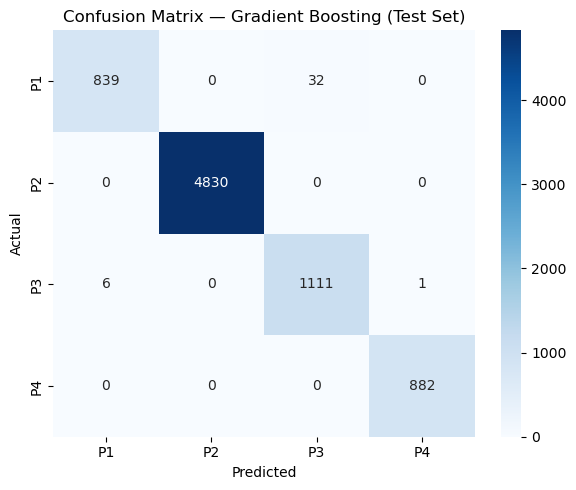

In [6]:
cm = confusion_matrix(y_test, test_pred, labels=['P1', 'P2', 'P3', 'P4'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['P1','P2','P3','P4'],
            yticklabels=['P1','P2','P3','P4'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_clf_name} (Test Set)')
plt.tight_layout()
plt.savefig('../figures/confusion_matrix.png', dpi=120)
plt.show()

## 6. Classifier Feature Importance

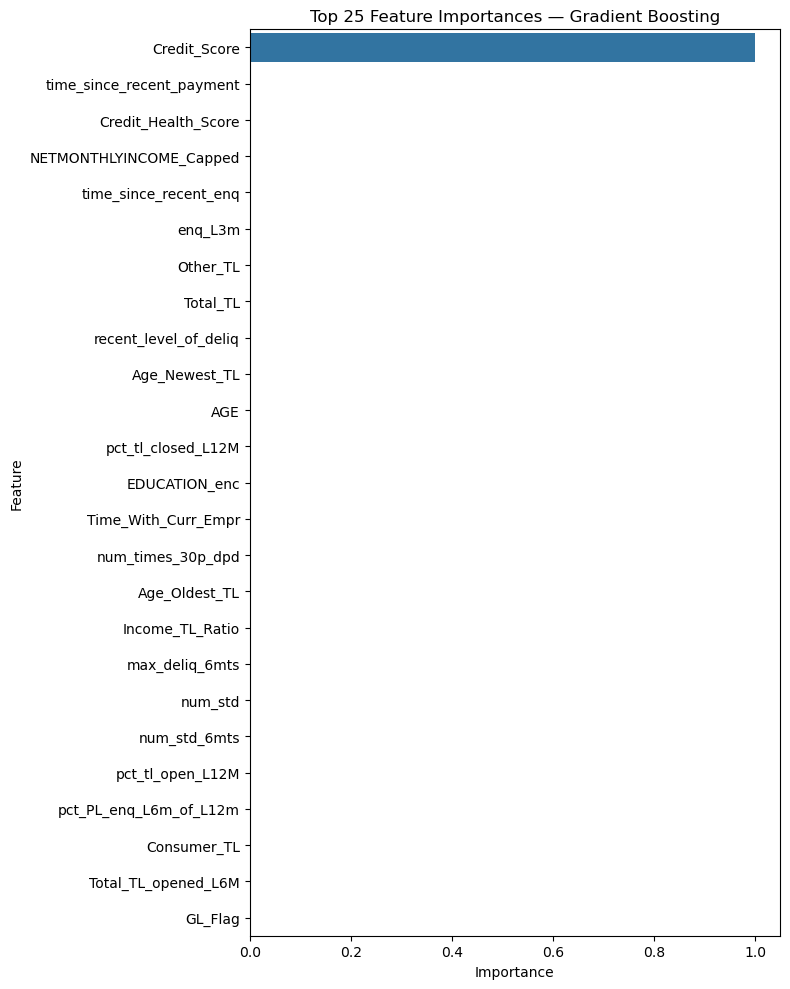

,Rank,Feature,Importance,Importance_Pct
0,1,Credit_Score,0.998971,99.897
1,2,time_since_recent_payment,0.000134,0.013
2,3,Credit_Health_Score,0.000110,0.011
3,4,NETMONTHLYINCOME_Capped,0.000078,0.008
4,5,time_since_recent_enq,0.000061,0.006
5,6,enq_L3m,0.000055,0.005
6,7,Other_TL,0.000053,0.005
7,8,Total_TL,0.000049,0.005
8,9,recent_level_of_deliq,0.000049,0.005
9,10,Age_Newest_TL,0.000040,0.004


In [7]:
if hasattr(best_clf, 'feature_importances_'):
    importances = pd.DataFrame({
        'Feature': FEATURE_COLS,
        'Importance': best_clf.feature_importances_
    }).sort_values('Importance', ascending=False).reset_index(drop=True)
    importances['Importance_Pct'] = (importances['Importance'] / importances['Importance'].sum() * 100).round(3)
    importances.insert(0, 'Rank', importances.index + 1)

    plt.figure(figsize=(8, 10))
    sns.barplot(data=importances.head(25), x='Importance', y='Feature')
    plt.title(f'Top 25 Feature Importances — {best_clf_name}')
    plt.tight_layout()
    plt.savefig('../figures/feature_importance.png', dpi=120)
    plt.show()

    importances.to_csv('../reports/feature_importance.csv', index=False)
    display(importances.head(15))
else:
    print(f"{best_clf_name} has no feature_importances_ attribute")

## 7. Regression — Predict Recommended Loan Amount

Historical bank data doesn't contain an observed "correct" loan amount (that's a policy decision, not an outcome), so there's no ground truth to regress against directly. We construct a defensible training target from real lending rules and train a regressor to learn that policy from the raw applicant features. The target is the **smallest** of three limits:

1. **Income multiple** — `annual income x tier multiplier x risk-adjustment` (from Credit_Health_Score).
2. **Tier cap** — the maximum loan the risk tier permits.
3. **Affordability (ideal-zone FOIR)** — the largest loan whose monthly EMI stays within the **ideal zone of 30% of net monthly income**, applied to every income level. Under 30%, the borrower's basic needs (food, rent, utilities, education) and their monthly savings/investments stay unaffected. This is the constraint that keeps the recommendation genuinely safe rather than merely repayable.

In [8]:
TIER_RULES = pd.DataFrame([
    dict(RiskTierID='P1', Risk_Category='Best Risk',     Eligibility_Status='Approved',
         Max_Loan_Amount=2_500_000, Interest_Rate_Pct=8.5,  Tenure_Years=5,
         Repayment_Method='EMI Fixed Monthly',  Income_Multiplier=5.0, Risk_Score_Range='750+'),
    dict(RiskTierID='P2', Risk_Category='Good Risk',     Eligibility_Status='Approved',
         Max_Loan_Amount=1_500_000, Interest_Rate_Pct=10.5, Tenure_Years=4,
         Repayment_Method='EMI Fixed Monthly',  Income_Multiplier=3.5, Risk_Score_Range='700-749'),
    dict(RiskTierID='P3', Risk_Category='Moderate Risk', Eligibility_Status='Conditional',
         Max_Loan_Amount=750_000,   Interest_Rate_Pct=13.5, Tenure_Years=3,
         Repayment_Method='EMI Step-Up',        Income_Multiplier=2.0, Risk_Score_Range='650-699'),
    dict(RiskTierID='P4', Risk_Category='High Risk',     Eligibility_Status='Rejected',
         Max_Loan_Amount=200_000,   Interest_Rate_Pct=18.0, Tenure_Years=2,
         Repayment_Method='Secured/Collateral', Income_Multiplier=0.5, Risk_Score_Range='<650'),
]).set_index('RiskTierID')

os.makedirs('../reports', exist_ok=True)
TIER_RULES.to_csv('../reports/dim_risk_tier.csv')
TIER_RULES

,Risk_Category,Eligibility_Status,Max_Loan_Amount,Interest_Rate_Pct,Tenure_Years,Repayment_Method,Income_Multiplier,Risk_Score_Range
RiskTierID,,,,,,,,
P1,Best Risk,Approved,2500000,8.5,5,EMI Fixed Monthly,5.0,750+
P2,Good Risk,Approved,1500000,10.5,4,EMI Fixed Monthly,3.5,700-749
P3,Moderate Risk,Conditional,750000,13.5,3,EMI Step-Up,2.0,650-699
P4,High Risk,Rejected,200000,18.0,2,Secured/Collateral,0.5,<650


In [9]:
def risk_adjustment(credit_health_score):
    return np.clip(0.6 + 0.4 * (credit_health_score / 100.0), 0.6, 1.0)

IDEAL_FOIR = 0.30  # ideal/safe zone: EMI under 30% of income for every income level

def max_foir(net_monthly_income=None):
    """EMI ceiling as a share of net monthly income. We size to the *ideal zone* --
    a flat 30% for everyone (low or high earner) -- so that after the EMI, basic
    needs (food, rent, utilities, education) and monthly savings stay unaffected."""
    return IDEAL_FOIR

def affordable_loan(net_monthly_income, annual_rate_pct, tenure_years):
    """Largest loan whose EMI stays within the FOIR limit for this income. Uses the
    customer's ACTUAL stated income so the EMI is genuinely affordable."""
    if net_monthly_income <= 0:
        return 0.0
    max_emi = max_foir(net_monthly_income) * net_monthly_income
    r = (annual_rate_pct / 100.0) / 12.0
    n = tenure_years * 12
    if r == 0:
        return max_emi * n
    annuity_factor = ((1 + r) ** n - 1) / (r * (1 + r) ** n)
    return max_emi * annuity_factor

def target_loan_amount(row):
    rule = TIER_RULES.loc[row[TARGET]]
    # A credit-risk factor from Credit_Health_Score (weaker payment history -> lower
    # factor -> smaller loan). Applied to BOTH the income-multiple and the
    # affordability limit, so credit history genuinely changes the amount.
    risk = risk_adjustment(row['Credit_Health_Score'])
    # income-multiple uses capped income (tames high-side data outliers);
    # affordability uses raw income (the real cashflow the EMI must fit within)
    by_income = row['NETMONTHLYINCOME_Capped'] * 12 * rule['Income_Multiplier'] * risk
    by_affordability = affordable_loan(row['NETMONTHLYINCOME'], rule['Interest_Rate_Pct'], rule['Tenure_Years']) * risk
    # smallest of: income-multiple, tier cap, risk-adjusted EMI affordability
    return min(by_income, rule['Max_Loan_Amount'], by_affordability)

df['Target_Loan_Amount'] = df.apply(target_loan_amount, axis=1)
print(df['Target_Loan_Amount'].describe())

y_amt = df['Target_Loan_Amount']
Xr_train, Xr_temp, yr_train, yr_temp = train_test_split(X, y_amt, test_size=0.30, random_state=42)
Xr_val, Xr_test, yr_val, yr_test = train_test_split(Xr_temp, yr_temp, test_size=0.50, random_state=42)

count    5.133600e+04
mean     2.318823e+05
std      1.429411e+05
min      0.000000e+00
25%      1.418016e+05
50%      1.964120e+05
75%      2.840812e+05
max      2.500000e+06
Name: Target_Loan_Amount, dtype: float64


In [10]:
# Monotonic constraint: a higher credit score / credit-health score must never LOWER the
# recommended loan. A plain Random Forest is not guaranteed monotonic, which caused a tiny
# non-monotonic dip at very high (data-sparse) credit scores. +1 = "can only push the loan up".
MONO_UP = ['Credit_Score', 'Credit_Health_Score']
monotonic_cst = [1 if c in MONO_UP else 0 for c in FEATURE_COLS]

regressors = {
    "Random Forest Regressor": RandomForestRegressor(n_estimators=50, max_depth=12, min_samples_leaf=8,
                                                     monotonic_cst=monotonic_cst, random_state=42, n_jobs=-1),
}

reg_results = []
fitted_regressors = {}
for name, reg in regressors.items():
    reg.fit(Xr_train, yr_train)
    val_pred = reg.predict(Xr_val)
    r2 = r2_score(yr_val, val_pred)
    mae = mean_absolute_error(yr_val, val_pred)
    reg_results.append({"Model": name, "Val_R2": r2, "Val_MAE": mae})
    fitted_regressors[name] = reg
    print(f"{name:25s} R2={r2:.4f}  MAE={mae:,.0f}")

reg_results_df = pd.DataFrame(reg_results).sort_values('Val_R2', ascending=False)
reg_results_df

Random Forest Regressor   R2=0.9596  MAE=5,762


,Model,Val_R2,Val_MAE
0,Random Forest Regressor,0.959581,5762.347833


Best regressor on validation: Random Forest Regressor
Test R2: 0.9595   Test MAE: Rs.6,052


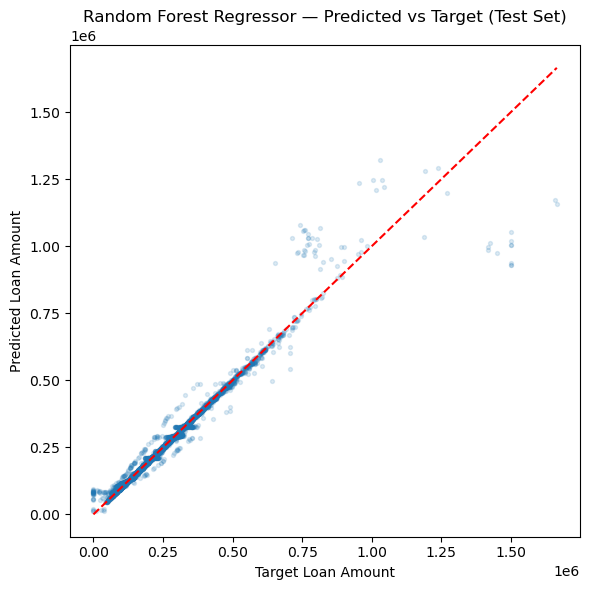

In [11]:
best_reg_name = reg_results_df.iloc[0]['Model']
best_reg = fitted_regressors[best_reg_name]
print(f"Best regressor on validation: {best_reg_name}")

test_pred = best_reg.predict(Xr_test)
test_r2 = r2_score(yr_test, test_pred)
test_mae = mean_absolute_error(yr_test, test_pred)
print(f"Test R2: {test_r2:.4f}   Test MAE: Rs.{test_mae:,.0f}")

plt.figure(figsize=(6, 6))
plt.scatter(yr_test, test_pred, alpha=0.15, s=8)
lims = [0, max(yr_test.max(), test_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Target Loan Amount')
plt.ylabel('Predicted Loan Amount')
plt.title(f'{best_reg_name} — Predicted vs Target (Test Set)')
plt.tight_layout()
plt.savefig('../figures/loan_amount_regression.png', dpi=120)
plt.show()

## 8. Save Model Performance Report

In [12]:
performance_rows = [
    ("Task", "Risk tier classification (Approved_Flag)"),
    ("Best Classifier", best_clf_name),
    ("Train Size", len(X_train)),
    ("Validation Size", len(X_val)),
    ("Test Size", len(X_test)),
    ("Total Features", len(FEATURE_COLS)),
    ("Target Classes", "P1, P2, P3, P4"),
    ("Test Accuracy", f"{test_acc*100:.2f}%"),
    ("Task ", "Loan amount regression"),
    ("Best Regressor", best_reg_name),
    ("Regression Test R2", f"{test_r2:.4f}"),
    ("Regression Test MAE", f"Rs.{test_mae:,.0f}"),
]
model_performance_df = pd.DataFrame(performance_rows, columns=["Metric", "Value"])
model_performance_df.to_csv('../reports/model_performance.csv', index=False)

# save the model metrics tables
clf_results_df.to_csv('../reports/classifier_comparison.csv', index=False)
reg_results_df.to_csv('../reports/regressor_comparison.csv', index=False)

model_performance_df

,Metric,Value
0,Task,Risk tier classification (Approved_Flag)
1,Best Classifier,Gradient Boosting
2,Train Size,35935
3,Validation Size,7700
4,Test Size,7701
5,Total Features,68
6,Target Classes,"P1, P2, P3, P4"
7,Test Accuracy,99.49%
8,Task,Loan amount regression
9,Best Regressor,Random Forest Regressor


## 9. Persist Models

Save the two best models — Gradient Boosting (risk tier) and the Random Forest Regressor (loan amount) — plus the feature-column list, for use in notebook 04 and the dashboard. The other algorithms above were trained only to justify this choice by comparison; they are intentionally **not** saved, so the project ships with a single model per task.

In [13]:
os.makedirs('../models', exist_ok=True)

# Save ONLY the single best model of each task -- these are the two the dashboard uses:
# Gradient Boosting for the risk tier, Random Forest Regressor for the loan amount.
# (The other algorithms were trained purely for the comparison above, not kept on disk.)
joblib.dump(best_clf, '../models/risk_tier_classifier.joblib', compress=3)
joblib.dump(best_reg, '../models/loan_amount_regressor.joblib', compress=3)
joblib.dump(FEATURE_COLS, '../models/feature_columns.joblib')
print(f"Saved the two best models: {best_clf_name} (classifier), {best_reg_name} (regressor)")

Saved the two best models: Gradient Boosting (classifier), Random Forest Regressor (regressor)


## 10. Reduced-Feature Model for Scoring `Unseen_Dataset.xlsx`

`Unseen_Dataset.xlsx` (the final holdout batch) only carries 42 of our 68 feature columns — notably it is **missing `Credit_Score` itself**, the single most important feature. This mirrors a real scenario where a bureau report is incomplete for some applicants. Rather than fabricate values for a field this important, we train a second, honestly-weaker classifier restricted only to the columns the unseen batch actually provides, and use *that* model to score it in notebook 04. The primary model above remains the one used for all customers with a full feature set.

In [14]:
unseen_df = pd.read_excel('../data/raw/Unseen_Dataset.xlsx')
unseen_cols = set(unseen_df.columns)

CAT_ENC_MAP = {'MARITALSTATUS_enc': 'MARITALSTATUS', 'EDUCATION_enc': 'EDUCATION',
               'GENDER_enc': 'GENDER', 'last_prod_enq2_enc': 'last_prod_enq2',
               'first_prod_enq2_enc': 'first_prod_enq2'}

reduced_feature_cols = [c for c in FEATURE_COLS if c in unseen_cols]
for enc_col, raw_col in CAT_ENC_MAP.items():
    if raw_col in unseen_cols and enc_col not in reduced_feature_cols:
        reduced_feature_cols.append(enc_col)

missing_from_unseen = [c for c in FEATURE_COLS if c not in reduced_feature_cols]
print(f"Reduced feature set: {len(reduced_feature_cols)} of {len(FEATURE_COLS)} columns available in Unseen_Dataset")
print(f"Columns NOT available for unseen scoring (including 'Credit_Score'): {len(missing_from_unseen)}")
print(missing_from_unseen)

Reduced feature set: 33 of 68 columns available in Unseen_Dataset
Columns NOT available for unseen scoring (including 'Credit_Score'): 35
['Total_TL', 'Tot_Active_TL', 'Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_active_tl', 'Total_TL_opened_L12M', 'pct_tl_open_L12M', 'Auto_TL', 'Consumer_TL', 'Gold_TL', 'num_times_delinquent', 'num_deliq_6mts', 'num_deliq_12mts', 'max_deliq_6mts', 'max_deliq_12mts', 'num_times_30p_dpd', 'num_std', 'num_std_6mts', 'num_dbt_6mts', 'num_lss_6mts', 'tot_enq', 'CC_enq', 'CC_enq_L6m', 'PL_enq', 'PL_enq_L6m', 'enq_L12m', 'AGE', 'pct_opened_TLs_L6m_of_L12m', 'pct_currentBal_all_TL', 'pct_PL_enq_L6m_of_L12m', 'pct_CC_enq_L6m_of_L12m', 'Credit_Score', 'NETMONTHLYINCOME_Capped', 'Income_TL_Ratio', 'Credit_Health_Score']


In [15]:
Xr_full = df[reduced_feature_cols]
Xr_train2, Xr_val2, yr_train2, yr_val2 = train_test_split(
    Xr_full, y, test_size=0.15, stratify=y, random_state=42)

reduced_clf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
reduced_clf.fit(Xr_train2, yr_train2)
reduced_val_pred = reduced_clf.predict(Xr_val2)
reduced_acc = accuracy_score(yr_val2, reduced_val_pred)
print(f"Reduced-feature model validation accuracy: {reduced_acc:.4f} "
      f"(vs {test_acc:.4f} for the full-feature model — expected drop since "
      f"Credit_Score itself is unavailable)")

joblib.dump(reduced_clf, '../models/risk_tier_classifier_reduced.joblib')
joblib.dump(reduced_feature_cols, '../models/reduced_feature_columns.joblib')
print("Saved reduced-feature model for unseen scoring.")

Reduced-feature model validation accuracy: 0.7490 (vs 0.9949 for the full-feature model — expected drop since Credit_Score itself is unavailable)
Saved reduced-feature model for unseen scoring.
